# Phase 5: Feature Engineering - Calendar Effects
In this notebook, we enrich the feature set with calendar-based identifiers. Time series models (particularly ML models like XGBoost/LightGBM) rely heavily on categorical datetime parts (hour, day, month) and strict boolean flags for anomalies like holidays or storms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load Feature Dataset
We load the dataset which now possesses our lags and rolling windows from Phase 4.

In [2]:
processed_dir = Path("../data/processed")
features_path = processed_dir / "features_hourly_demand.parquet"

# Load and ensure index is sorted datetime
df = pd.read_parquet(features_path)
if 'timestamp' in df.columns:
    df.set_index('timestamp', inplace=True)

df.sort_index(inplace=True)

print(f"Loaded Time Series with shape: {df.shape}")
df.head(3)

Loaded Time Series with shape: (10177, 26)


,total_demand,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rolling_mean_6,rolling_std_6,rolling_max_6,...,rolling_std_24,rolling_max_24,rolling_min_24,rolling_mean_168,rolling_std_168,rolling_max_168,rolling_min_168,ewma_span_12,ewma_span_24,ewma_span_72
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00,6610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 01:00:00,7481,6610.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6610.0,6610.00,6610.000000
2025-01-01 02:00:00,6126,7481.0,6610.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6744.0,6679.68,6633.863014


## 2. Extract Date Parts
Models often struggle to parse raw timestamps. We explicitly decode the cyclic properties of time into distinct numeric and categorical columns.

In [3]:
# Extract components
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
# 0 = Monday, 6 = Sunday
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

df['day_of_month'] = df.index.day
df['month'] = df.index.month
df['quarter'] = df.index.quarter

df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24.0)

## 3. Flag US & NYC Public Holidays

In [4]:
# Get US holidays specific to New York state for the years spanning our dataset
years = list(df.index.year.unique())
ny_holidays = holidays.US(state='NY', years=years)

# We check if the date component of our index falls on a holiday
df['is_holiday'] = df.index.map(lambda x: x.date() in ny_holidays).astype(int)
print(f"Total holiday hours flagged in dataset: {sum(df['is_holiday'])}")

Total holiday hours flagged in dataset: 456


## 4. Visualizing Calendar Effects
We can look at average demand across hours to quickly assert our calendar logic.

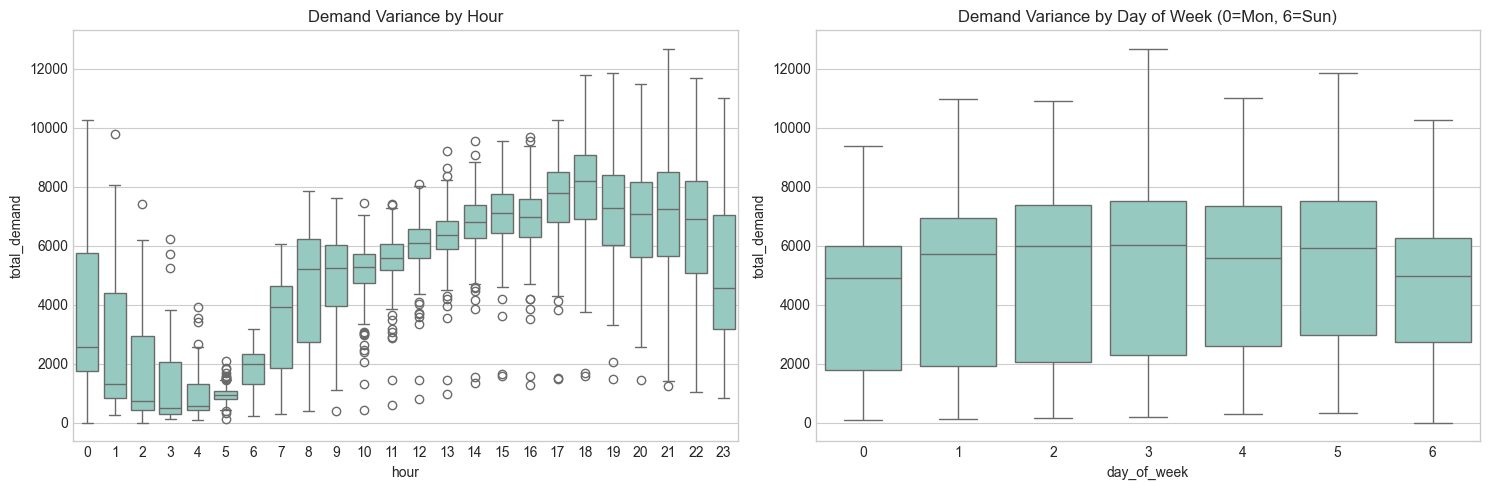

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Average Demand by Hour of Day
sns.boxplot(data=df, x='hour', y='total_demand', ax=axes[0])
axes[0].set_title('Demand Variance by Hour')

# Average Demand Day of Week
sns.boxplot(data=df, x='day_of_week', y='total_demand', ax=axes[1])
axes[1].set_title('Demand Variance by Day of Week (0=Mon, 6=Sun)')

plt.tight_layout()
plt.show()

## 5. Save the Fully Engineered Dataset
The dataset is now fully packed with lag features, moving averages, and calendar variables. It is completely ready for Machine Learning modeling!

In [6]:
final_features_path = processed_dir / "final_ml_features.parquet"

# Save the dataframe
df.to_parquet(final_features_path)
print(f"Saved FINAL feature-engineered ML dataset to {final_features_path}")

# Quick info
df.info()

Saved FINAL feature-engineered ML dataset to ..\data\processed\final_ml_features.parquet
<class 'pandas.DataFrame'>
DatetimeIndex: 10177 entries, 2025-01-01 00:00:00 to 2026-03-01 00:00:00
Data columns (total 35 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   total_demand      10177 non-null  int64  
 1   lag_1             10176 non-null  float64
 2   lag_2             10175 non-null  float64
 3   lag_3             10174 non-null  float64
 4   lag_24            10153 non-null  float64
 5   lag_48            10129 non-null  float64
 6   lag_168           10009 non-null  float64
 7   rolling_mean_6    10171 non-null  float64
 8   rolling_std_6     10171 non-null  float64
 9   rolling_max_6     10171 non-null  float64
 10  rolling_min_6     10171 non-null  float64
 11  rolling_mean_12   10165 non-null  float64
 12  rolling_std_12    10165 non-null  float64
 13  rolling_max_12    10165 non-null  float64
 14  rolling_min_12    101